In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
df = pd.read_csv("StudentPerformanceFactors.csv")

print("Shape:", df.shape)
df.head()

Shape: (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
df_clean = df.copy()

le = LabelEncoder()

for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = le.fit_transform(df_clean[col])

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

In [5]:
inertia = []
silhouette = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

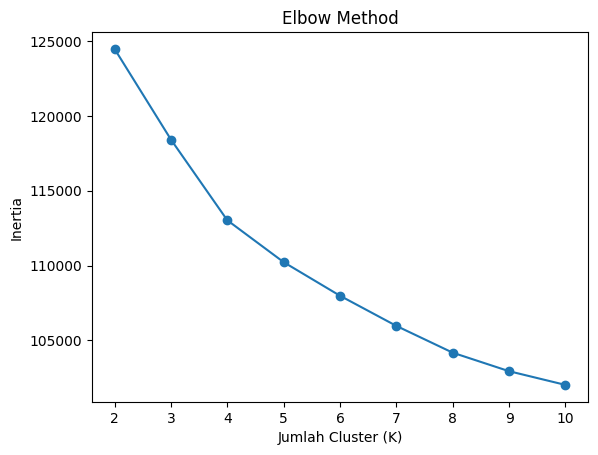

In [6]:
plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Inertia")
plt.show()

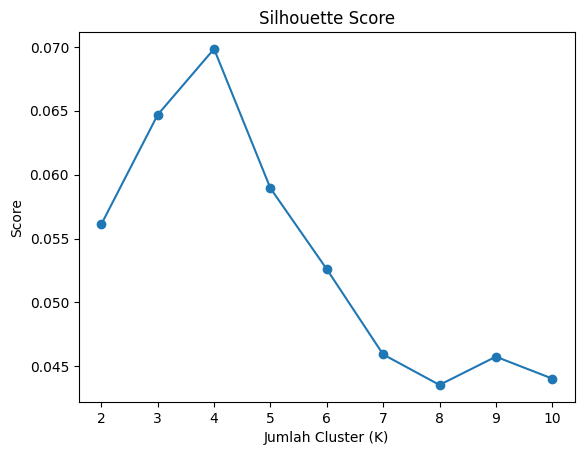

In [7]:
plt.figure()
plt.plot(K_range, silhouette, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Score")
plt.show()

In [8]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df_clean["Cluster_KMeans"] = kmeans.fit_predict(X_scaled)

print("Silhouette KMeans:", round(silhouette_score(X_scaled, df_clean["Cluster_KMeans"]), 3))

Silhouette KMeans: 0.065


In [9]:
agg = AgglomerativeClustering(n_clusters=optimal_k)
df_clean["Cluster_Hierarchical"] = agg.fit_predict(X_scaled)

print("Silhouette Hierarchical:", round(
    silhouette_score(X_scaled, df_clean["Cluster_Hierarchical"]), 3))

Silhouette Hierarchical: 0.129


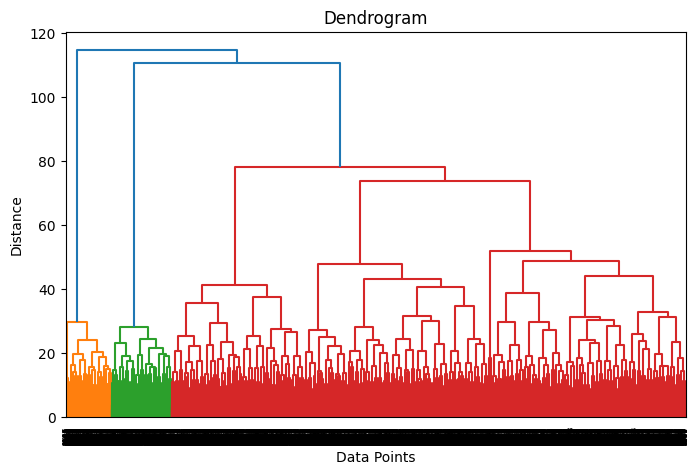

In [10]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(8,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [11]:
cluster_profile = df_clean.groupby("Cluster_KMeans").mean()
cluster_profile

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Cluster_Hierarchical
Cluster_KMeans,,,,,,,,,,,,,,,,,,,,,
0,18.384640,71.932011,1.292729,1.281398,0.582940,7.035883,73.701291,1.277306,1.000000,1.361977,...,1.389676,0.693421,1.124016,2.977337,0.129682,0.905886,1.455146,0.571923,64.668870,0.259994
1,21.719304,88.575375,1.142224,1.120396,0.608799,7.031719,76.597203,1.340382,0.999659,1.630286,...,1.249318,0.702251,1.258868,2.949181,0.079809,0.954297,1.562074,0.587312,70.147681,0.152797
2,19.855422,80.682731,1.214859,1.194779,0.604418,6.969880,74.817269,1.307229,0.000000,1.530120,...,1.331325,0.674699,1.216867,3.014056,0.098394,0.857430,1.534137,0.552209,66.465863,0.993976


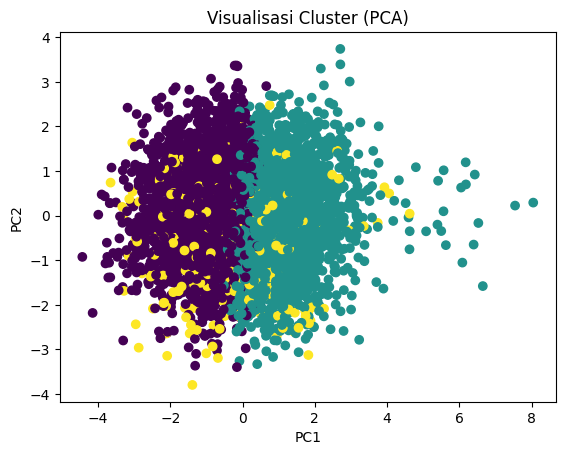

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=df_clean["Cluster_KMeans"])
plt.title("Visualisasi Cluster (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()